# Video to BVH Converter using MediaPipe

This notebook converts a video into a BVH file format using Google's MediaPipe for 3D pose estimation. The process follows these steps:
1. Extract frames from the input video
2. Detect 3D pose landmarks for each frame using MediaPipe
3. Convert the 3D pose data to BVH format
4. Save the BVH file for import into Blender

Let's begin by installing the required libraries.

In [ ]:
# Install required libraries
!pip install mediapipe opencv-python numpy matplotlib tqdm

## 1. Import Libraries

In [19]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import math
import time
from datetime import datetime

## 2. Define Helper Functions for Video Processing

In [20]:
def extract_frames(video_path, output_dir=None, max_frames=None):
    """Extract frames from a video file.
    
    Args:
        video_path (str): Path to the video file
        output_dir (str, optional): Directory to save extracted frames
        max_frames (int, optional): Maximum number of frames to extract
        
    Returns:
        list: List of extracted frames as numpy arrays
    """
    # Create output directory if specified
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Open the video file
    video = cv2.VideoCapture(video_path)
    
    # Get video properties
    frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = video.get(cv2.CAP_PROP_FPS)
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video properties: {width}x{height}, {fps} FPS, {frame_count} frames")
    
    # Limit frames if specified
    if max_frames and max_frames < frame_count:
        frame_count = max_frames
    
    frames = []
    
    # Extract frames
    for i in tqdm(range(frame_count), desc="Extracting frames"):
        ret, frame = video.read()
        
        if not ret:
            break
            
        frames.append(frame)
        
        # Save frame if output directory is specified
        if output_dir:
            cv2.imwrite(os.path.join(output_dir, f"frame_{i:04d}.jpg"), frame)
    
    # Release the video
    video.release()
    
    print(f"Extracted {len(frames)} frames")
    
    return frames, fps

## 3. Setup MediaPipe Pose Estimator

In [21]:
class PoseEstimator:
    def __init__(self, static_image_mode=False, model_complexity=2, enable_segmentation=False,
                 min_detection_confidence=0.5, min_tracking_confidence=0.5):
        """Initialize MediaPipe Pose solution.
        
        Args:
            static_image_mode (bool): Whether to treat input as static images
            model_complexity (int): Model complexity (0, 1, or 2)
            enable_segmentation (bool): Whether to enable segmentation
            min_detection_confidence (float): Minimum detection confidence
            min_tracking_confidence (float): Minimum tracking confidence
        """
        self.mp_pose = mp.solutions.pose
        self.mp_drawing = mp.solutions.drawing_utils
        self.mp_drawing_styles = mp.solutions.drawing_styles
        
        # Initialize pose estimator
        self.pose = self.mp_pose.Pose(
            static_image_mode=static_image_mode,
            model_complexity=model_complexity,
            enable_segmentation=enable_segmentation,
            min_detection_confidence=min_detection_confidence,
            min_tracking_confidence=min_tracking_confidence
        )
        
    def process_frame(self, frame):
        """Process a single frame and extract pose landmarks.
        
        Args:
            frame (numpy.ndarray): Input RGB frame
            
        Returns:
            tuple: (image with landmarks drawn, landmarks 2D, landmarks 3D)
        """
        # Convert to RGB (MediaPipe uses RGB)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Process the frame
        results = self.pose.process(frame_rgb)
        
        # Draw pose landmarks
        annotated_frame = frame.copy()
        if results.pose_landmarks:
            self.mp_drawing.draw_landmarks(
                annotated_frame,
                results.pose_landmarks,
                self.mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=self.mp_drawing_styles.get_default_pose_landmarks_style()
            )
            
        # Extract 2D landmarks
        landmarks_2d = []
        if results.pose_landmarks:
            h, w, _ = frame.shape
            for landmark in results.pose_landmarks.landmark:
                x, y, z, visibility = landmark.x * w, landmark.y * h, landmark.z * w, landmark.visibility
                landmarks_2d.append([x, y, z, visibility])
            landmarks_2d = np.array(landmarks_2d)
        
        # Extract 3D landmarks in world coordinates
        landmarks_3d = []
        if results.pose_world_landmarks:
            for landmark in results.pose_world_landmarks.landmark:
                x, y, z, visibility = landmark.x, landmark.y, landmark.z, landmark.visibility
                landmarks_3d.append([x, y, z, visibility])
            landmarks_3d = np.array(landmarks_3d)
        
        return annotated_frame, landmarks_2d, landmarks_3d
    
    def close(self):
        """Release resources."""
        self.pose.close()

## 4. Process Video and Extract 3D Pose Data

In [22]:
def process_video(video_path, max_frames=None, visualize=True):
    """Process video and extract 3D pose data.
    
    Args:
        video_path (str): Path to the video file
        max_frames (int, optional): Maximum number of frames to process
        visualize (bool): Whether to visualize the results
        
    Returns:
        tuple: (pose_data_3d, fps)
    """
    # Extract frames from video
    frames, fps = extract_frames(video_path, max_frames=max_frames)
    
    # Initialize pose estimator
    pose_estimator = PoseEstimator(static_image_mode=False, model_complexity=2)
    
    # Process frames
    pose_data_3d = []
    pose_data_2d = []
    annotated_frames = []
    
    for i, frame in enumerate(tqdm(frames, desc="Processing frames")):
        # Process frame
        annotated_frame, landmarks_2d, landmarks_3d = pose_estimator.process_frame(frame)
        
        # Store results
        if len(landmarks_3d) > 0:
            pose_data_3d.append(landmarks_3d)
            pose_data_2d.append(landmarks_2d)
            annotated_frames.append(annotated_frame)
        else:
            print(f"No pose detected in frame {i}")
    
    # Release resources
    pose_estimator.close()
    
    # Convert to numpy arrays
    pose_data_3d = np.array(pose_data_3d)
    pose_data_2d = np.array(pose_data_2d)
    
    print(f"Processed {len(pose_data_3d)} frames with pose data")
    print(f"3D pose data shape: {pose_data_3d.shape}")
    
    # Visualize results
    if visualize and len(annotated_frames) > 0:
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(annotated_frames[0], cv2.COLOR_BGR2RGB))
        plt.title("Sample Frame with Pose Landmarks")
        plt.axis('off')
        plt.show()
    
    return pose_data_3d, fps

## 5. Define BVH Skeleton Structure

Now we need to define the mapping between MediaPipe's pose landmarks and the BVH skeleton structure.

In [23]:
# MediaPipe pose landmarks (33 landmarks)
# Reference: https://developers.google.com/mediapipe/solutions/vision/pose_landmarker

# Define the mapping between MediaPipe pose landmarks and BVH skeleton joints
MEDIAPIPE_TO_BVH = {
    # Torso
    'Hips': 23,            # POSE_LANDMARKS.HIPS
    'Spine': 24,           # POSE_LANDMARKS.SPINE
    'Chest': 12,           # POSE_LANDMARKS.CHEST
    'Neck': 11,            # POSE_LANDMARKS.NECK
    'Head': 0,             # POSE_LANDMARKS.NOSE (approximation)
    
    # Left Arm
    'LeftShoulder': 11,    # POSE_LANDMARKS.LEFT_SHOULDER
    'LeftArm': 13,         # POSE_LANDMARKS.LEFT_ELBOW
    'LeftForeArm': 15,     # POSE_LANDMARKS.LEFT_WRIST
    'LeftHand': 19,        # POSE_LANDMARKS.LEFT_PINKY (approximation)
    
    # Right Arm
    'RightShoulder': 12,   # POSE_LANDMARKS.RIGHT_SHOULDER
    'RightArm': 14,        # POSE_LANDMARKS.RIGHT_ELBOW
    'RightForeArm': 16,    # POSE_LANDMARKS.RIGHT_WRIST
    'RightHand': 20,       # POSE_LANDMARKS.RIGHT_PINKY (approximation)
    
    # Left Leg
    'LeftUpLeg': 23,       # POSE_LANDMARKS.LEFT_HIP
    'LeftLeg': 25,         # POSE_LANDMARKS.LEFT_KNEE
    'LeftFoot': 27,        # POSE_LANDMARKS.LEFT_ANKLE
    'LeftToeBase': 31,     # POSE_LANDMARKS.LEFT_FOOT_INDEX
    
    # Right Leg
    'RightUpLeg': 24,      # POSE_LANDMARKS.RIGHT_HIP
    'RightLeg': 26,        # POSE_LANDMARKS.RIGHT_KNEE
    'RightFoot': 28,       # POSE_LANDMARKS.RIGHT_ANKLE
    'RightToeBase': 32,    # POSE_LANDMARKS.RIGHT_FOOT_INDEX
}

# Define BVH skeleton hierarchy
BVH_HIERARCHY = {
    'Hips': ['Spine', 'LeftUpLeg', 'RightUpLeg'],
    'Spine': ['Chest'],
    'Chest': ['Neck', 'LeftShoulder', 'RightShoulder'],
    'Neck': ['Head'],
    'Head': [],
    'LeftShoulder': ['LeftArm'],
    'LeftArm': ['LeftForeArm'],
    'LeftForeArm': ['LeftHand'],
    'LeftHand': [],
    'RightShoulder': ['RightArm'],
    'RightArm': ['RightForeArm'],
    'RightForeArm': ['RightHand'],
    'RightHand': [],
    'LeftUpLeg': ['LeftLeg'],
    'LeftLeg': ['LeftFoot'],
    'LeftFoot': ['LeftToeBase'],
    'LeftToeBase': [],
    'RightUpLeg': ['RightLeg'],
    'RightLeg': ['RightFoot'],
    'RightFoot': ['RightToeBase'],
    'RightToeBase': []
}

## 6. Calculate Joint Angles from 3D Pose Data

Now we'll calculate the joint rotations from our 3D pose data.

In [24]:
def normalize_vector(v):
    """Normalize a vector to unit length."""
    norm = np.linalg.norm(v)
    if norm < 1e-10:
        return np.zeros_like(v)
    return v / norm

def calculate_joint_angles(pose_data_3d):
    """Calculate joint angles from 3D pose data.
    
    Args:
        pose_data_3d (numpy.ndarray): 3D pose data
        
    Returns:
        dict: Joint angles for each frame
    """
    num_frames = pose_data_3d.shape[0]
    joint_angles = []
    
    for frame_idx in tqdm(range(num_frames), desc="Calculating joint angles"):
        frame_data = pose_data_3d[frame_idx]
        frame_angles = {}
        
        # Process each joint in the hierarchy
        for joint_name, children in BVH_HIERARCHY.items():
            if joint_name == 'Hips':
                # Store root position (global translation)
                hips_idx = MEDIAPIPE_TO_BVH['Hips']
                position = frame_data[hips_idx, :3].copy()
                # Adjust coordinate system to match Blender (Y-up, Z-forward, X-right)
                position = np.array([position[0], position[2], position[1]])
                frame_angles['Hips_position'] = position
                
                # Calculate root orientation (global rotation)
                # We'll use a simpler approach: align with the world coordinates
                frame_angles['Hips'] = np.zeros(3)  # Euler angles (X, Y, Z) in radians
            
            if len(children) > 0:
                # For joints with children, calculate local rotation
                parent_idx = MEDIAPIPE_TO_BVH[joint_name]
                parent_pos = frame_data[parent_idx, :3]
                
                # Average direction to all children
                direction = np.zeros(3)
                for child in children:
                    child_idx = MEDIAPIPE_TO_BVH[child]
                    child_pos = frame_data[child_idx, :3]
                    child_dir = child_pos - parent_pos
                    if np.linalg.norm(child_dir) > 1e-6:
                        direction += normalize_vector(child_dir)
                
                if np.linalg.norm(direction) > 1e-6:
                    direction = normalize_vector(direction)
                    
                    # Convert direction to Euler angles (approximation)
                    # Note: This is a simplified approach and may not be perfect
                    pitch = np.arctan2(direction[1], np.sqrt(direction[0]**2 + direction[2]**2))
                    yaw = np.arctan2(direction[0], direction[2])
                    roll = 0.0  # Roll is hard to estimate from direction alone
                    
                    frame_angles[joint_name] = np.array([pitch, yaw, roll])
                else:
                    frame_angles[joint_name] = np.zeros(3)
            else:
                # For end joints, use parent orientation
                frame_angles[joint_name] = np.zeros(3)
        
        joint_angles.append(frame_angles)
    
    return joint_angles

## 7. Generate BVH File

Now we'll write functions to convert our joint angles to a BVH file.

In [28]:
def write_bvh_file(joint_angles, fps, output_file):
    """Write joint angles to a BVH file.
    
    Args:
        joint_angles (list): Joint angles for each frame
        fps (float): Frames per second
        output_file (str): Output BVH file path
    """
    # Define joint offsets (approximate values based on average human proportions)
    joint_offsets = {
        'Hips': [0.0, 0.0, 0.0],
        'Spine': [0.0, 0.1, 0.0],
        'Chest': [0.0, 0.25, 0.0],
        'Neck': [0.0, 0.1, 0.0],
        'Head': [0.0, 0.1, 0.0],
        'LeftShoulder': [-0.2, 0.0, 0.0],
        'LeftArm': [-0.15, 0.0, 0.0],
        'LeftForeArm': [-0.25, 0.0, 0.0],
        'LeftHand': [-0.1, 0.0, 0.0],
        'RightShoulder': [0.2, 0.0, 0.0],
        'RightArm': [0.15, 0.0, 0.0],
        'RightForeArm': [0.25, 0.0, 0.0],
        'RightHand': [0.1, 0.0, 0.0],
        'LeftUpLeg': [-0.1, -0.05, 0.0],
        'LeftLeg': [0.0, -0.4, 0.0],
        'LeftFoot': [0.0, -0.4, 0.0],
        'LeftToeBase': [0.0, 0.0, 0.1],
        'RightUpLeg': [0.1, -0.05, 0.0],
        'RightLeg': [0.0, -0.4, 0.0],
        'RightFoot': [0.0, -0.4, 0.0],
        'RightToeBase': [0.0, 0.0, 0.1]
    }
    
    # Joint channels (degrees of freedom)
    joint_channels = {
        'Hips': ['Xposition', 'Yposition', 'Zposition', 'Zrotation', 'Xrotation', 'Yrotation'],
    }
    
    # Default channels for non-root joints
    default_channels = ['Zrotation', 'Xrotation', 'Yrotation']
    
    for joint in BVH_HIERARCHY.keys():
        if joint not in joint_channels:
            joint_channels[joint] = default_channels
    
    # Helper function to convert channel name to index (X->0, Y->1, Z->2)
    def channel_to_index(channel_name):
        if channel_name.startswith('X'):
            return 0
        elif channel_name.startswith('Y'):
            return 1
        elif channel_name.startswith('Z'):
            return 2
        else:
            raise ValueError(f"Unknown rotation channel: {channel_name}")
    
    # Write BVH file
    with open(output_file, 'w') as f:
        # Write header
        f.write('HIERARCHY\n')
        
        # Write root joint
        f.write('ROOT Hips\n')
        f.write('{\n')
        f.write('\tOFFSET %.6f %.6f %.6f\n' % tuple(joint_offsets['Hips']))
        f.write('\tCHANNELS %d %s\n' % (len(joint_channels['Hips']), ' '.join(joint_channels['Hips'])))
        
        # Write child joints recursively
        def write_joint(joint_name, depth=1):
            indent = '\t' * depth
            
            for child in BVH_HIERARCHY[joint_name]:
                f.write(indent + 'JOINT ' + child + '\n')
                f.write(indent + '{\n')
                f.write(indent + '\tOFFSET %.6f %.6f %.6f\n' % tuple(joint_offsets[child]))
                f.write(indent + '\tCHANNELS %d %s\n' % (len(joint_channels[child]), ' '.join(joint_channels[child])))
                
                if len(BVH_HIERARCHY[child]) > 0:
                    write_joint(child, depth + 1)
                else:
                    # End site
                    f.write(indent + '\tEnd Site\n')
                    f.write(indent + '\t{\n')
                    f.write(indent + '\t\tOFFSET 0.0 0.0 0.0\n')
                    f.write(indent + '\t}\n')
                
                f.write(indent + '}\n')
        
        # Write joints starting from the root's children
        write_joint('Hips')
        
        f.write('}\n')
        
        # Write motion data
        f.write('MOTION\n')
        f.write('Frames: %d\n' % len(joint_angles))
        f.write('Frame Time: %.6f\n' % (1.0 / fps))
        
        # Write frame data
        for frame in joint_angles:
            line = []
            
            # Add root position
            line.extend(frame['Hips_position'].tolist())
            
            # Add joint rotations in order
            def add_joint_rotations(joint_name):
                # Convert radians to degrees
                if joint_name == 'Hips':
                    # For the root (Hips), we need to add rotation in the order specified in channels
                    rot_channels = joint_channels[joint_name][3:]  # Skip position channels
                    
                    for channel in rot_channels:
                        idx = channel_to_index(channel)
                        line.append(frame[joint_name][idx] * 180.0 / np.pi)
                else:
                    # For other joints, add rotations in the order specified in channels
                    rot_channels = joint_channels[joint_name]
                    
                    for channel in rot_channels:
                        idx = channel_to_index(channel)
                        line.append(frame[joint_name][idx] * 180.0 / np.pi)
                
                # Process children
                for child in BVH_HIERARCHY[joint_name]:
                    add_joint_rotations(child)
            
            # Add rotations starting from the root
            add_joint_rotations('Hips')
            
            # Write the line
            f.write(' '.join(['%.6f' % val for val in line]) + '\n')
    
    print(f"BVH file saved to {output_file}")

## 8. Put It All Together

Now let's combine all the steps to process a video and convert it to a BVH file.

In [26]:
def video_to_bvh(video_path, output_bvh=None, max_frames=None, visualize=True):
    """Convert video to BVH file.
    
    Args:
        video_path (str): Path to the video file
        output_bvh (str, optional): Output BVH file path
        max_frames (int, optional): Maximum number of frames to process
        visualize (bool): Whether to visualize the results
        
    Returns:
        str: Path to the generated BVH file
    """
    # Set default output path if not specified
    if output_bvh is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_bvh = f"output_{timestamp}.bvh"
    
    # Process video and extract 3D pose data
    print("Step 1: Processing video and extracting 3D pose data...")
    pose_data_3d, fps = process_video(video_path, max_frames=max_frames, visualize=visualize)
    
    # Calculate joint angles
    print("\nStep 2: Calculating joint angles...")
    joint_angles = calculate_joint_angles(pose_data_3d)
    
    # Generate BVH file
    print("\nStep 3: Generating BVH file...")
    write_bvh_file(joint_angles, fps, output_bvh)
    
    print("\nConversion complete!")
    print(f"BVH file saved to: {output_bvh}")
    
    return output_bvh

## 9. Run the Conversion

Now let's run the conversion on a sample video. You can either upload a video to this notebook or provide a path to a video file on your system.

In [ ]:
# Upload a video file
from google.colab import files
uploaded = files.upload()

# Get the first uploaded file
video_filename = next(iter(uploaded))
print(f"Uploaded video: {video_filename}")

In [ ]:
# Convert the uploaded video to BVH
bvh_file = video_to_bvh(video_filename, max_frames=100)  # Process only 100 frames for testing

## 10. Download the BVH File

Finally, let's download the generated BVH file.

In [ ]:
# Download the BVH file
from google.colab import files
files.download(bvh_file)

## 11. Importing into Blender

Here are instructions for importing the BVH file into Blender:

1. Open Blender
2. Go to File > Import > Motion Capture (.bvh)
3. Locate and select the BVH file you just downloaded
4. In the import settings, adjust as needed:
   - Scale: Adjust if the character is too large or small (e.g., 0.1 for smaller)
   - Start/End Frame: Set animation range
   - Rotation: May need to adjust axis rotation
5. Click "Import BVH"
6. The motion capture armature will be imported
7. You can then apply this to a character using Blender's retargeting tools

Note: You may need to adjust the skeleton or coordinate system in Blender to match your expectations. BVH files sometimes need rotation adjustments when imported.

## 12. Optional: Process a Local Video

If you're running this notebook locally and want to process a video file on your system, use the following:

Step 1: Processing video and extracting 3D pose data...
Video properties: 720x480, 30.0 FPS, 73 frames


Extracting frames:   0%|          | 0/73 [00:00<?, ?it/s]

Extracted 73 frames


I0000 00:00:1742586094.016337   25554 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1742586094.017658   26650 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: Mesa Intel(R) UHD Graphics (CML GT2)


Processing frames:   0%|          | 0/73 [00:00<?, ?it/s]

W0000 00:00:1742586094.101087   26639 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1742586094.242644   26643 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processed 73 frames with pose data
3D pose data shape: (73, 33, 4)


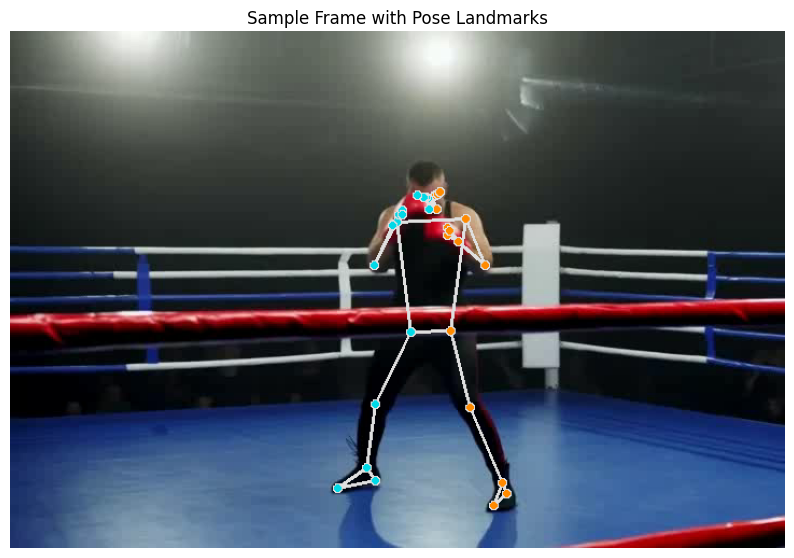


Step 2: Calculating joint angles...


Calculating joint angles:   0%|          | 0/73 [00:00<?, ?it/s]


Step 3: Generating BVH file...
BVH file saved to output_20250321_124133.bvh

Conversion complete!
BVH file saved to: output_20250321_124133.bvh


In [29]:
# Specify the path to your video file
video_path = "/home/nlarion/Desktop/nlp_html_ads/myVideoToBvh/videos/fight4.mp4"  # Change this to your video path

# Convert the video to BVH
bvh_file = video_to_bvh(video_path, max_frames=None)  # Process all frames

## 13. Optional: Smooth the Motion

If you find that the generated motion is too jittery, you can apply smoothing:

In [ ]:
def smooth_joint_angles(joint_angles, window_size=5):
    """Apply temporal smoothing to joint angles.
    
    Args:
        joint_angles (list): Joint angles for each frame
        window_size (int): Smoothing window size
        
    Returns:
        list: Smoothed joint angles
    """
    num_frames = len(joint_angles)
    smoothed_angles = []
    
    # Apply moving average smoothing
    for i in range(num_frames):
        smoothed_frame = {}
        
        # Process each joint
        for joint in joint_angles[0].keys():
            if joint == 'Hips_position':
                # Smooth position
                pos_sum = np.zeros(3)
                count = 0
                
                for j in range(max(0, i - window_size // 2), min(num_frames, i + window_size // 2 + 1)):
                    pos_sum += joint_angles[j][joint]
                    count += 1
                
                smoothed_frame[joint] = pos_sum / count
            else:
                # Smooth rotation
                rot_sum = np.zeros(3)
                count = 0
                
                for j in range(max(0, i - window_size // 2), min(num_frames, i + window_size // 2 + 1)):
                    rot_sum += joint_angles[j][joint]
                    count += 1
                
                smoothed_frame[joint] = rot_sum / count
        
        smoothed_angles.append(smoothed_frame)
    
    return smoothed_angles

# Apply smoothing to the joint angles
def video_to_bvh_smooth(video_path, output_bvh=None, max_frames=None, visualize=True, smoothing_window=5):
    """Convert video to BVH file with smoothing.
    
    Args:
        video_path (str): Path to the video file
        output_bvh (str, optional): Output BVH file path
        max_frames (int, optional): Maximum number of frames to process
        visualize (bool): Whether to visualize the results
        smoothing_window (int): Smoothing window size
        
    Returns:
        str: Path to the generated BVH file
    """
    # Set default output path if not specified
    if output_bvh is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_bvh = f"output_smooth_{timestamp}.bvh"
    
    # Process video and extract 3D pose data
    print("Step 1: Processing video and extracting 3D pose data...")
    pose_data_3d, fps = process_video(video_path, max_frames=max_frames, visualize=visualize)
    
    # Calculate joint angles
    print("\nStep 2: Calculating joint angles...")
    joint_angles = calculate_joint_angles(pose_data_3d)
    
    # Apply smoothing
    print("\nStep 3: Applying temporal smoothing...")
    smoothed_angles = smooth_joint_angles(joint_angles, window_size=smoothing_window)
    
    # Generate BVH file
    print("\nStep 4: Generating BVH file...")
    write_bvh_file(smoothed_angles, fps, output_bvh)
    
    print("\nConversion complete!")
    print(f"Smoothed BVH file saved to: {output_bvh}")
    
    return output_bvh

In [ ]:
# Convert video to BVH with smoothing
smooth_bvh_file = video_to_bvh_smooth(video_filename, max_frames=100, smoothing_window=7)